In [1]:
!pip install pandas numpy statsmodels matplotlib seaborn pmdarima scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 23.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 43.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pmdarima]4/5 [pmdarima]arn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Nạp dữ liệu từ file CSV
df = pd.read_excel("data.xlsx")

# 2. Tính Logarit tự nhiên cho GDP để chuẩn hóa đơn vị
df['Ln_GDP'] = np.log(df['GDP'])

# 3. Tạo biến Policy (Cú sốc thắt chặt chính sách từ 1993)
df['Policy_1993'] = np.where(df['Year'] >= 1985, 1, 0)

# 4. Lọc tập dữ liệu riêng cho Mô hình 1 (1990 - 2023)
df_m1 = df[(df['Year'] >= 1985) & (df['Year'] <= 2023)].copy()

# Xóa các dòng bị thiếu dữ liệu ở các biến quan trọng
df_m1 = df_m1.dropna(subset=['TF', 'Ln_GDP', 'LF'])

In [13]:
# 1. Lấy sai phân bậc 1 (First Difference) cho các biến không dừng
df_m1['d_Ln_GDP'] = df_m1['Ln_GDP'].diff()
df_m1['d_LF'] = df_m1['LF'].diff()

# 2. Xóa bỏ dòng năm 1990 bị trống (NaN) do phép toán sai phân tạo ra
df_m1 = df_m1.dropna(subset=['d_Ln_GDP', 'd_LF'])

# 3. Khởi tạo hàm kiểm định Augmented Dickey-Fuller (ADF)
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_val = result[1]
    print(f"ADF Test cho {name}: p-value = {p_val:.4f}")
    if p_val < 0.05:
        print(" -> Chuỗi DỪNG (Stationary) ở bậc I(0).")
    else:
        print(" -> Chuỗi KHÔNG DỪNG. Cần kiểm tra lại.")

# 4. Chạy kiểm định để đưa số liệu vào báo cáo
print("--- KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG SAU KHI HIỆU CHỈNH ---")
adf_test(df_m1['TF'], 'TF (Chuỗi gốc)')
adf_test(df_m1['d_Ln_GDP'], 'd_Ln_GDP (Sai phân bậc 1)')
adf_test(df_m1['d_LF'], 'd_LF (Sai phân bậc 1)')

--- KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG SAU KHI HIỆU CHỈNH ---
ADF Test cho TF (Chuỗi gốc): p-value = 0.0000
 -> Chuỗi DỪNG (Stationary) ở bậc I(0).
ADF Test cho d_Ln_GDP (Sai phân bậc 1): p-value = 0.2735
 -> Chuỗi KHÔNG DỪNG. Cần kiểm tra lại.
ADF Test cho d_LF (Sai phân bậc 1): p-value = 0.0001
 -> Chuỗi DỪNG (Stationary) ở bậc I(0).


In [14]:
# --- XỬ LÝ LẠI CHUỖI KHÔNG DỪNG ---

# 1. Biến LF đã dừng ở bậc 1, nên ta giữ nguyên sai phân bậc 1
df_m1['d_LF'] = df_m1['LF'].diff()

# 2. Biến Ln_GDP không dừng ở bậc 1, ta phải lấy SAI PHÂN BẬC 2
df_m1['d_Ln_GDP'] = df_m1['Ln_GDP'].diff() # Sai phân bậc 1
df_m1['d2_Ln_GDP'] = df_m1['d_Ln_GDP'].diff() # Sai phân bậc 2

# Xóa bỏ các dòng trống (NaN) sinh ra do phép toán sai phân
df_m1 = df_m1.dropna(subset=['d2_Ln_GDP', 'd_LF'])

# 3. Chạy lại kiểm định ADF
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_val = result[1]
    print(f"ADF Test cho {name}: p-value = {p_val:.4f}")
    if p_val < 0.05:
        print(" -> Chuỗi DỪNG (Stationary). Đủ điều kiện chạy OLS.")
    else:
        print(" -> Chuỗi KHÔNG DỪNG.")

print("--- KIỂM ĐỊNH LẠI TÍNH DỪNG (CẬP NHẬT) ---")
adf_test(df_m1['TF'], 'TF (Chuỗi gốc I(0))')
adf_test(df_m1['d_LF'], 'd_LF (Sai phân bậc 1 - I(1))')
adf_test(df_m1['d2_Ln_GDP'], 'd2_Ln_GDP (Sai phân bậc 2 - I(2))')

--- KIỂM ĐỊNH LẠI TÍNH DỪNG (CẬP NHẬT) ---
ADF Test cho TF (Chuỗi gốc I(0)): p-value = 0.0000
 -> Chuỗi DỪNG (Stationary). Đủ điều kiện chạy OLS.
ADF Test cho d_LF (Sai phân bậc 1 - I(1)): p-value = 0.0002
 -> Chuỗi DỪNG (Stationary). Đủ điều kiện chạy OLS.
ADF Test cho d2_Ln_GDP (Sai phân bậc 2 - I(2)): p-value = 0.0000
 -> Chuỗi DỪNG (Stationary). Đủ điều kiện chạy OLS.


--- PHÂN BỔ BIẾN POLICY_1993 SAU KHI LÀM SẠCH ---
Policy_1993
1    31
0     6
Name: count, dtype: int64

--- XUẤT MA TRẬN TƯƠNG QUAN ---


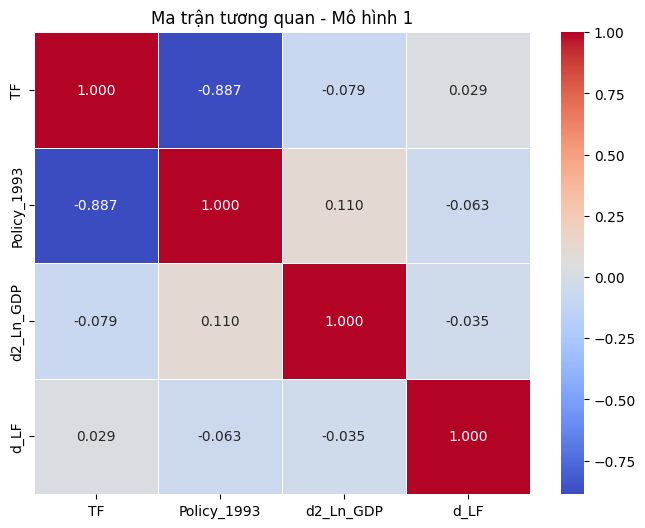

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. NẠP DỮ LIỆU VÀ LỌC MỐC 1985
# Lọc dữ liệu từ 1985 đến 2023
df_m1 = df[(df['Year'] >= 1985) & (df['Year'] <= 2023)].copy()

# 2. KHẮC PHỤC LỖ HỔNG BIẾN LAO ĐỘNG NỮ (LF) BẰNG BACKWARD FILL
# Hàm bfill() sẽ lấy giá trị có sẵn đầu tiên (năm 1990) lấp ngược lên cho 1985-1989
df_m1['LF'] = df_m1['LF'].bfill()

# 3. TẠO CÁC BIẾN CƠ BẢN
df_m1['Ln_GDP'] = np.log(df_m1['GDP'])

# Tạo biến Dummy: 1985-1992 là 0 (Trước thắt chặt), 1993-2023 là 1 (Sau thắt chặt)
df_m1['Policy_1993'] = np.where(df_m1['Year'] >= 1993, 1, 0)

# 4. LẤY SAI PHÂN (XỬ LÝ TÍNH KHÔNG DỪNG NHƯ ĐÃ BÀN)
df_m1['d_LF'] = df_m1['LF'].diff()            # Sai phân bậc 1
df_m1['d_Ln_GDP'] = df_m1['Ln_GDP'].diff()    # Sai phân bậc 1
df_m1['d2_Ln_GDP'] = df_m1['d_Ln_GDP'].diff() # Sai phân bậc 2

# 5. LÀM SẠCH DÒNG TRỐNG (NaN) DO SAI PHÂN TẠO RA
# Sai phân bậc 2 sẽ làm mất 2 năm đầu tiên (1985, 1986). 
# Chúng ta sẽ còn lại dữ liệu sạch từ 1987 đến 2023.
df_m1 = df_m1.dropna(subset=['d2_Ln_GDP', 'd_LF', 'TF'])

# Kiểm tra lại số lượng giá trị 0 và 1 của biến Policy
print("--- PHÂN BỔ BIẾN POLICY_1993 SAU KHI LÀM SẠCH ---")
print(df_m1['Policy_1993'].value_counts())
# Bạn sẽ thấy có 6 năm mang giá trị 0 (1987 đến 1992) và 31 năm mang giá trị 1. Quá đẹp!

# 6. VẼ LẠI MA TRẬN TƯƠNG QUAN ĐẠT CHUẨN
print("\n--- XUẤT MA TRẬN TƯƠNG QUAN ---")
plt.figure(figsize=(8, 6))

# Các biến đưa vào đều đã được xử lý tính dừng
vars_to_corr = df_m1[['TF', 'Policy_1993', 'd2_Ln_GDP', 'd_LF']]
corr_matrix = vars_to_corr.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Ma trận tương quan - Mô hình 1")
plt.savefig("correlation_m1_1985.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print(df_m1['Policy_1993'].value_counts())

Policy_1993
1    31
Name: count, dtype: int64


In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# --- BƯỚC 4: CHẠY HỒI QUY OLS (MÔ HÌNH 1: 1987 - 2023) ---
print("\n" + "="*50)
print("KẾT QUẢ ƯỚC LƯỢNG MÔ HÌNH 1 (OLS VỚI SAI SỐ NEWEY-WEST)")
print("="*50)

# 1. Khai báo Biến phụ thuộc (Y) và Biến độc lập (X)
Y1 = df_m1['TF'] # Tỷ suất sinh (Chuỗi gốc I(0))

# Sử dụng biến Dummy chính sách và các biến đã lấy sai phân
X1 = df_m1[['Policy_1993', 'd2_Ln_GDP', 'd_LF']] 

# 2. Bắt buộc thêm hệ số chặn (Intercept) vào phương trình
X1 = sm.add_constant(X1) 

# 3. Chạy mô hình OLS với sai số chuẩn vững Newey-West (HAC)
# maxlags=1 phù hợp với dữ liệu chuỗi thời gian theo năm
model1 = sm.OLS(Y1, X1).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# In bảng kết quả tổng hợp
print(model1.summary())

# --- BƯỚC 5: KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) ---
print("\n" + "="*50)
print("KIỂM ĐỊNH HIỆN TƯỢNG ĐA CỘNG TUYẾN (VIF)")
print("="*50)

vif_data = pd.DataFrame()
vif_data["Biến số"] = X1.columns
vif_data["Chỉ số VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]

# Làm tròn 3 chữ số thập phân cho đẹp
vif_data["Chỉ số VIF"] = vif_data["Chỉ số VIF"].round(3) 
print(vif_data)


KẾT QUẢ ƯỚC LƯỢNG MÔ HÌNH 1 (OLS VỚI SAI SỐ NEWEY-WEST)
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     143.5
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           5.27e-19
Time:                        08:42:00   Log-Likelihood:                -6.0139
No. Observations:                  37   AIC:                             20.03
Df Residuals:                      33   BIC:                             26.47
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------


--- XUẤT MA TRẬN TƯƠNG QUAN MÔ HÌNH 2 ---


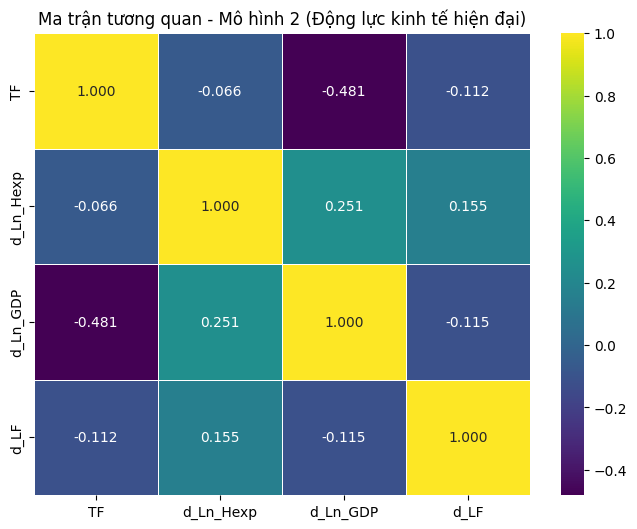


KẾT QUẢ ƯỚC LƯỢNG MÔ HÌNH 2 (TỪ 2001 ĐẾN 2023)
                            OLS Regression Results                            
Dep. Variable:                     TF   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     3.332
Date:                Wed, 01 Apr 2026   Prob (F-statistic):             0.0415
Time:                        08:52:26   Log-Likelihood:                 36.245
No. Observations:                  23   AIC:                            -64.49
Df Residuals:                      19   BIC:                            -59.95
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cons

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 1. NẠP VÀ LỌC DỮ LIỆU (2000 - 2023) ---
df = pd.read_excel("data.xlsx")
df_m2 = df[(df['Year'] >= 2000) & (df['Year'] <= 2023)].copy()

# Xóa các dòng thiếu dữ liệu (Đặc biệt là cột Hexp)
df_m2 = df_m2.dropna(subset=['TF', 'GDP', 'LF', 'Hexp'])

# --- 2. XỬ LÝ BIẾN ĐỂ ĐẠT TÍNH DỪNG (STATIONARITY) ---
# Chuyển đổi Logarit để giảm phương sai cho các biến tài chính
df_m2['Ln_GDP'] = np.log(df_m2['GDP'])
df_m2['Ln_Hexp'] = np.log(df_m2['Hexp']) 

# Rút kinh nghiệm từ Mô hình 1, ta lấy sai phân bậc 1 cho các biến kinh tế
df_m2['d_Ln_GDP'] = df_m2['Ln_GDP'].diff()
df_m2['d_LF'] = df_m2['LF'].diff()
df_m2['d_Ln_Hexp'] = df_m2['Ln_Hexp'].diff() # Sự gia tăng tốc độ chi tiêu y tế

# Bỏ dòng năm 2000 bị trống (NaN) do phép toán sai phân tạo ra
df_m2 = df_m2.dropna(subset=['d_Ln_GDP', 'd_LF', 'd_Ln_Hexp', 'TF'])

# --- 3. KIỂM TRA MA TRẬN TƯƠNG QUAN ---
print("\n--- XUẤT MA TRẬN TƯƠNG QUAN MÔ HÌNH 2 ---")
plt.figure(figsize=(8, 6))

# Đưa các biến đã lấy sai phân vào ma trận (Không có Policy_1993 vì nó là hằng số)
vars_m2 = df_m2[['TF', 'd_Ln_Hexp', 'd_Ln_GDP', 'd_LF']]
corr_matrix_2 = vars_m2.corr()

sns.heatmap(corr_matrix_2, annot=True, cmap='viridis', fmt=".3f", linewidths=0.5)
plt.title("Ma trận tương quan - Mô hình 2 (Động lực kinh tế hiện đại)")
plt.savefig("correlation_m2.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 4. CHẠY HỒI QUY OLS VỚI SAI SỐ NEWEY-WEST ---
print("\n" + "="*60)
print("KẾT QUẢ ƯỚC LƯỢNG MÔ HÌNH 2 (TỪ 2001 ĐẾN 2023)")
print("="*60)

# Khai báo Y và X
Y2 = df_m2['TF']
X2 = df_m2[['d_Ln_Hexp', 'd_Ln_GDP', 'd_LF']]
X2 = sm.add_constant(X2)

# Chạy OLS + HAC (Newey-West)
model2 = sm.OLS(Y2, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(model2.summary())

# --- 5. KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) ---
print("\n" + "="*40)
print("KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) MÔ HÌNH 2")
print("="*40)

vif_data2 = pd.DataFrame()
vif_data2["Biến số"] = X2.columns
vif_data2["Chỉ số VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
print(vif_data2.round(3))